# Predicción temperaturas estación de Jena, Alemania



El objetivo es **predecir la temperatura con 24 horas de antelación** basándose en datos meteorológicos (como presión, humedad, etc.) registrados cada hora en la estación de Jena, Alemania.

### 1. Introducción a las Series Temporales

- **Definición:** Una serie temporal es cualquier dato medido a intervalos regulares (ej: precio de acciones, consumo eléctrico, clima).
- **Desafío Clave:** A diferencia de otros datos, las series temporales implican comprender la **dinámica** de un sistema: sus ciclos (diarios, anuales), tendencias y eventos anómalos.
- **Tipos de Tareas:**
    - **Pronóstico (Forecasting):** La más común y el foco del capítulo. Predecir valores futuros.
    - **Clasificación:** Asignar una etiqueta a una serie temporal (ej: determinar si un usuario es un bot).
    - **Detección de Eventos:** Identificar un suceso específico (ej: "Ok Google").
    - **Detección de Anomalías:** Encontrar patrones inusuales.

### 2. El Problema: Pronóstico del Clima de Jena

- **Objetivo:** Dado el historial de datos de los últimos 5 días (con una medición por hora), predecir la temperatura que habrá 24 horas después.
- **Datos:** Dataset del Instituto Max Planck de Jena, con 14 variables meteorológicas registradas cada 10 minutos desde 2009 hasta 2016.
- **Preparación de Datos:**
    - **Normalización:** Se normalizan todas las características (restar la media y dividir por la desviación estándar) usando solo los datos de entrenamiento para no "contaminar" los conjuntos de validación y test.
    - **División de Datos:** Se dividen los datos cronológicamente: 50% para entrenamiento, 25% para validación y 25% para test. Es crucial que los datos de validación/test sean más recientes que los de entrenamiento.
    - **Generador de Datos:** Se utiliza la utilidad `timeseries_dataset_from_array` de Keras para generar lotes de datos "al vuelo", evitando gastar memoria. Cada muestra de entrada contiene 120 pasos de tiempo (5 días x 24 horas) con 14 características cada uno.

### 3. El Proceso Iterativo de Modelado (de lo simple a lo complejo)

Seguiremos un enfoque práctico, construyendo y evaluando varios modelos para demostrar qué funciona y por qué.

1. **Línea Base de Sentido Común (Baseline):**
    - **Estrategia:** Predecir que la temperatura en 24 horas será la misma que la temperatura actual.
    - **Resultado:** Se obtiene un Error Absoluto Medio (MAE) de **2.62 grados Celsius**. Este es el umbral a superar para demostrar que el machine learning es útil.
2. **Modelo Básico de Machine Learning (Red Densa):**
    - **Arquitectura:** Se "aplana" la serie temporal (se convierte la secuencia en un vector largo) y se pasa por dos capas densas.
    - **Resultado:** Apenas mejora la línea base.
    - **Lección:** Aplanar los datos **destruye la noción de tiempo y orden**, que es fundamental. Este enfoque no es adecuado.
3. **Modelo Convolucional 1D (Conv1D):**
    - **Idea:** Intentar que una red convolucional capture patrones temporales (como los ciclos diarios).
    - **Resultado:** Funciona peor que la línea base.
    - **Lección:** Las redes convolucionales asumen "invariancia a la traslación" (un patrón es el mismo sin importar dónde aparezca). Sin embargo, en el clima, un patrón por la mañana tiene propiedades diferentes a uno por la noche. Además, las capas de pooling destruyen información de orden crucial.
4. **Primer Modelo Recurrente (LSTM):**
    - **Arquitectura:** Se introduce la **Red Neuronal Recurrente (RNN)**, diseñada específicamente para procesar secuencias. Se utiliza una capa **LSTM (Long Short-Term Memory)**.
    - **Resultado:** ¡Éxito! El MAE de prueba baja a **2.55 grados**, superando por primera vez la línea base.
    - **Lección:** Los modelos recurrentes, que procesan los datos paso a paso manteniendo un "estado" o memoria, son la herramienta adecuada para este tipo de problema.

### 4. Profundización en las Redes Recurrentes (RNNs)

- **Concepto Clave de RNN:** Una RNN procesa una secuencia iterando a través de sus elementos. En cada paso, combina la entrada actual con su "estado" anterior para producir una salida y actualizar su estado.
- **El Problema del Gradiente Desvanecido:** Las RNN simples (SimpleRNN) tienen dificultades para aprender dependencias a largo plazo (información de hace muchos pasos).
- **LSTM y GRU como Solución:** Las capas **LSTM** y **GRU (Gated Recurrent Unit)** son variantes avanzadas de RNN que incluyen mecanismos (llamados "puertas") para controlar qué información se guarda, se olvida y se transmite a través del tiempo. Esto les permite manejar secuencias largas de manera efectiva. El capítulo explica visualmente cómo funciona una celda LSTM con su "cinta transportadora" de información (carry track).  

### 5. Técnicas Avanzadas para Mejorar el Modelo RNN

1. **Dropout Recurrente:**
    - **Problema:** El modelo LSTM básico sobreajusta (overfitting) rápidamente.
    - **Solución:** Se aplica una forma especial de dropout donde la misma "máscara" de dropout (las mismas neuronas desactivadas) se usa en cada paso de tiempo. Keras lo implementa con los argumentos dropout y recurrent_dropout.
    - **Resultado:** El sobreajuste se reduce drásticamente y el MAE de prueba mejora a **2.45 grados**.
2. **Apilamiento de Capas Recurrentes (Stacking):**
    - **Idea:** Aumentar la capacidad del modelo apilando varias capas recurrentes una encima de la otra (similar a apilar capas en una red convolucional). Para esto, las capas intermedias deben devolver la secuencia completa (`return_sequences=True`).
    - **Resultado:** Se obtiene una ligera mejora adicional, alcanzando un MAE de **2.39 grados**.
3. **RNNs Bidireccionales:**
    - **Idea:** Procesar la secuencia en ambas direcciones (cronológica y anti-cronológica) y combinar los resultados. Es muy útil en tareas como el procesamiento de lenguaje natural.
    - **Resultado:** En el problema del clima, este enfoque **empeora los resultados**.
    - **Lección:** Para el clima, el pasado más reciente es mucho más predictivo que el pasado lejano. La parte anti-cronológica de la red no aprende nada útil y solo añade parámetros, causando sobreajuste.
        


### 6. Conclusiones Finales

- Siempre establece una **línea base de sentido común** antes de probar modelos complejos.
- Para datos donde el orden importa, como las series temporales, las **RNNs (LSTM, GRU) son la herramienta ideal**.
- Técnicas como el **dropout recurrente** son esenciales para regularizar las RNNs.
- **No existe una solución única:** cada dataset es diferente y requiere experimentación.
- **Advertencia importante:** El capítulo desaconseja firmemente aplicar estas técnicas al **mercado de valores**. A diferencia del clima, el rendimiento pasado no es un buen predictor del futuro en los mercados financieros, que son sistemas de "arbitraje de información" y no fenómenos naturales predecibles.

### 1: Configuración del Entorno y Descarga de Datos

Primero, necesitamos descargar el conjunto de datos meteorológicos de Jena y descomprimirlo. Usaremos comandos de terminal directamente en Colab anteponiendo !. También importaremos la librería os para manejar las rutas de los archivos.




In [12]:
from tensorflow import keras

In [1]:
import os
# Descargar y descomprimir el archivo de datos
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip
# Definir la ruta al archivo CSV
fname = os.path.join("jena_climate_2009_2016.csv")

--2025-07-13 10:43:58--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.173.208, 52.217.40.70, 52.216.238.5, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.173.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  62.1MB/s    in 0.2s    

2025-07-13 10:43:58 (62.1 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


### 2: Lectura e Inspección de los Datos

Ahora leeremos el archivo CSV y lo cargaremos en la memoria.

Nos fijamos que la frecuencia de los datos es de 10 minutos. Luego cambiaremos eso.

In [19]:
import pandas as pd
import numpy as np

# Cargar el archivo CSV en un DataFrame de pandas
# La ruta 'fname' fue definida en el Tramo 1
df = pd.read_csv(fname)

# --- Inspección de los datos (reemplaza el antiguo Tramo 2) ---
print("Primeras 5 filas del DataFrame:")
print(df.head())
print("\nInformación del DataFrame:")
df.info()

header = df.columns.tolist()
print("\nCabecera (nombres de columnas):", header)
print(f"\nNúmero total de registros: {len(df)}")

Número de filas antes de limpiar: 420451
Número de filas después de limpiar: 420451

Primeras 5 filas del DataFrame limpio:
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08         

### 3: Parseo de Datos a Arrays de NumPy

El siguiente paso es convertir los datos de texto en arrays numéricos de NumPy, que es el formato que necesitan las redes neuronales. Crearemos dos arrays:

1. temperature: Un array 1D solo con los valores de temperatura (nuestro objetivo a predecir).
2. raw_data: Un array 2D con todas las 14 características meteorológicas (nuestros datos de entrada).

Descartamos la primera columna ("Date Time") porque no es numérica.

In [20]:
# --- Parseo de datos a NumPy
# Extraer la columna de temperatura y convertirla a un array de NumPy
temperature = df['T (degC)'].to_numpy()

# Extraer todas las características (todas las columnas desde la segunda en adelante)
# y convertirlas a un array de NumPy.
# df.iloc[:, 1:] selecciona todas las filas (:) y todas las columnas desde el índice 1 hasta el final
raw_data = df.iloc[:, 1:].to_numpy()


# --- Verificación final de las formas de los arrays ---
print("\nForma del array de datos brutos:", raw_data.shape)
print("Forma del array de temperatura:", temperature.shape)


Forma del array de datos brutos: (420451, 14)
Forma del array de temperatura: (420451,)




### 4: Visualización de los Datos

Es fundamental visualizar los datos para entender sus patrones. Primero, graficaremos la serie temporal completa de la temperatura para ver sus ciclos anuales. Luego, haremos un zoom en los primeros 10 días para observar los ciclos diarios.




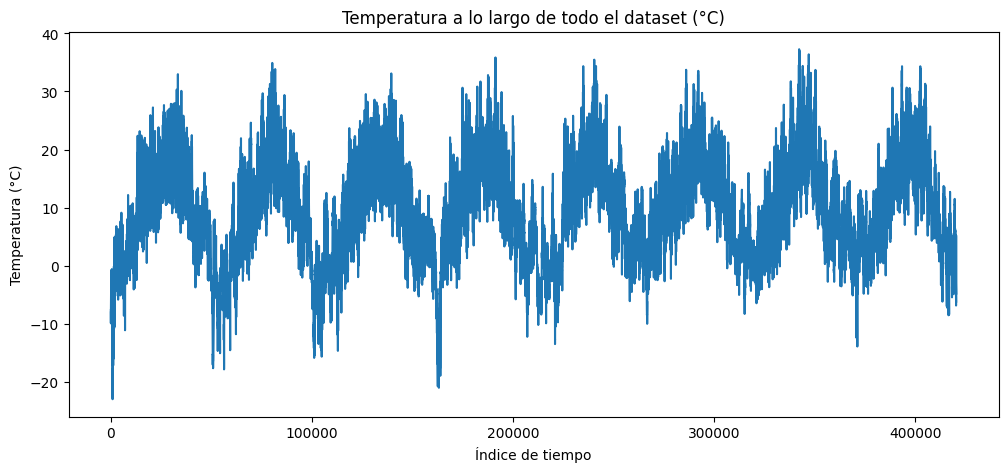

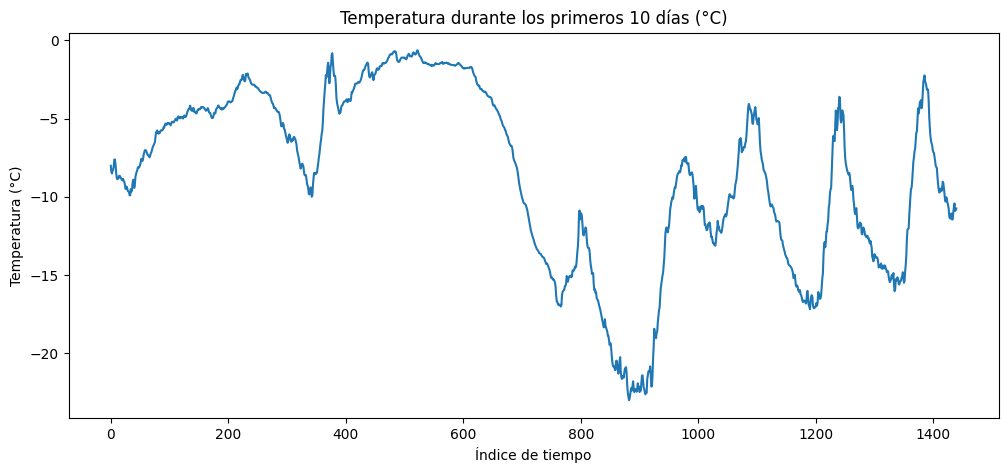

In [21]:
      # Celda 4
from matplotlib import pyplot as plt
# Gráfico de la temperatura a lo largo de todo el dataset
plt.figure(figsize=(12, 5))
plt.plot(range(len(temperature)), temperature)
plt.title("Temperatura a lo largo de todo el dataset (°C)")
plt.xlabel("Índice de tiempo")
plt.ylabel("Temperatura (°C)")
plt.show()
# Gráfico de la temperatura en los primeros 10 días
# 10 días * 24 horas/día * 6 registros/hora = 1440 registros
plt.figure(figsize=(12, 5))
plt.plot(range(1440), temperature[:1440])
plt.title("Temperatura durante los primeros 10 días (°C)")
plt.xlabel("Índice de tiempo")
plt.ylabel("Temperatura (°C)")
plt.show()



### 5: Preparación de Datos para el Modelo

Este es un paso crucial que incluye varias subtareas:

1. **División de Datos:** Dividimos los datos cronológicamente: 50% para entrenamiento, 25% para validación y 25% para prueba.


In [22]:
# 1. División de Datos
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("Muestras de entrenamiento:", num_train_samples)
print("Muestras de validación:", num_val_samples)
print("Muestras de prueba:", num_test_samples)

Muestras de entrenamiento: 210225
Muestras de validación: 105112
Muestras de prueba: 105114


2. **Normalización:** Normalizamos los datos (restar la media y dividir por la desviación estándar). Es muy importante que la media y la desviación se calculen **únicamente sobre el conjunto de entrenamiento** para no "filtrar" información de los conjuntos de validación/prueba.


In [23]:
# 2. Normalización de Datos
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

3. **Creación de los Datasets:** Usamos la utilidad timeseries_dataset_from_array de Keras para crear generadores de datos que produzcan lotes de secuencias de entrada y sus objetivos correspondientes.




In [24]:
# 3. Creación de los Datasets
sampling_rate = 6  # 1 punto por hora (originalmente era cada 10 min)
sequence_length = 120  # Usar 120 horas (5 días) de datos pasados
delay = sampling_rate * (sequence_length + 24 - 1) # Objetivo: 24h después del final de la secuencia
batch_size = 256

In [25]:
# Dataset de entrenamiento
train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)
# Dataset de validación
val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)
# Dataset de prueba
test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

In [26]:
# Inspeccionar la forma de un lote
for samples, targets in train_dataset:
    print("\nForma de las muestras (batch, timesteps, features):", samples.shape)
    print("Forma de los objetivos (batch,):", targets.shape)
    break


Forma de las muestras (batch, timesteps, features): (256, 120, 14)
Forma de los objetivos (batch,): (256,)




### 6: Modelo 1 - Línea Base de Sentido Común

Antes de usar machine learning, establecemos una línea base simple: predecir que la temperatura en 24 horas será igual a la temperatura actual. Calcularemos el Error Absoluto Medio (MAE) de este método. La temperatura que necesitamos está en la última posición (-1) de la secuencia, y es la característica en el índice 1.




In [27]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        # La predicción es el último valor de temperatura de la secuencia de entrada
        # samples[:, -1, 1] es el último timestep de la característica de temperatura
        # Deshacemos la normalización para obtener el error en °C
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen
print(f"Validation MAE (naive): {evaluate_naive_method(val_dataset):.2f} grados")
print(f"Test MAE (naive): {evaluate_naive_method(test_dataset):.2f} grados")


Validation MAE (naive): 2.44 grados
Test MAE (naive): 2.62 grados


Estos resultados significan un límite a lo mal que lo puede hacer nuestro modelo, no es admisible que decir "*mañana hará la misma temperatura que hoy*" sea mejor método para predecir la temperatura que nuestro modelo.



### 7: Modelo 2 - Red Densa Básica (No recurrente)

Nuestro primer intento con machine learning. Aplanamos la secuencia temporal y la pasamos por una red densa. Usamos ModelCheckpoint para guardar el mejor modelo durante el entrenamiento.

(Ha habido que modificar la forma en la que hace el Flatten para forzar una única dimensión)


In [31]:
# Celda 7 (CORRECCIÓN FINAL con Reshape)
from tensorflow.keras import layers
from tensorflow import keras

# Definimos las dimensiones numéricamente para mayor claridad
num_features = 14
timesteps = 120 # = sequence_length

inputs = keras.Input(shape=(timesteps, num_features))
# ---- CORRECCIÓN: Reemplazar Flatten() por una capa Reshape() explícita ----
# En lugar de aplanar, hacemos un reshape a un vector 1D.
# La nueva forma será (timesteps * num_features,).
# Antes:
# x = layers.Flatten()(inputs)
# Ahora:
x = layers.Reshape((timesteps * num_features,))(inputs)
# -------------------------------------------------------------------------

x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

# Inspeccionar el modelo para ver si las formas son correctas
model.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

# Cargar el mejor modelo y evaluar
model = keras.models.load_model("jena_dense.keras")
print(f"\nTest MAE (dense): {model.evaluate(test_dataset)[1]:.2f} grados")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │        26,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,913 (105.13 KB)

 Trainable params: 26,913 (105.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 64ms/step - loss: 23.7122 - mae: 3.6722 - val_loss: 11.1507 - val_mae: 2.6545
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 10.3952 - mae: 2.5362 - val_loss: 11.3295 - val_mae: 2.6601
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 9.3844 - mae: 2.4139 - val_loss: 11.1728 - val_mae: 2.6491
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - loss: 8.7095 - mae: 2.3256 - val_loss: 13.8831 - val_mae: 2.9611
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 8.2686 - mae: 2.2662 - val_loss: 11.8656 - val_mae: 2.7391
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 7.9717 - mae: 2.2233 - val_loss: 12.6579 - val_mae: 2.8378
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 7.6261 - mae: 2.1770 - val_loss: 12.9515 - val_mae: 2.8587
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 7.4225 - mae: 2.1485 - val_loss: 13.2354 - val_mae: 2.9061
Epoch 9/10
819/819 ━━━━━━━━━━━



### 8: Modelo 3 - Red Convolucional 1D

Probamos con una red convolucional 1D, que a veces puede capturar patrones locales en secuencias. Como veremos, tampoco es la mejor herramienta para este problema.




In [32]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_conv.keras")
print(f"\nTest MAE (conv1d): {model.evaluate(test_dataset)[1]:.2f} grados")
# Esperado: ~2.9, peor que la línea base.

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 84s 100ms/step - loss: 33.3732 - mae: 4.3590 - val_loss: 18.6050 - val_mae: 3.3729
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 79s 96ms/step - loss: 15.3831 - mae: 3.1117 - val_loss: 16.2682 - val_mae: 3.1979
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 84s 99ms/step - loss: 13.8887 - mae: 2.9493 - val_loss: 14.2864 - val_mae: 2.9748
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 79s 96ms/step - loss: 12.9014 - mae: 2.8426 - val_loss: 14.9899 - val_mae: 3.0443
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 76s 93ms/step - loss: 12.2136 - mae: 2.7642 - val_loss: 14.0487 - val_mae: 2.9447
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 78s 95ms/step - loss: 11.6790 - mae: 2.7014 - val_loss: 14.1098 - val_mae: 2.9549
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 78s 95ms/step - loss: 11.1748 - mae: 2.6416 - val_loss: 13.8531 - val_mae: 2.9214
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 78s 95ms/step - loss: 10.8381 - mae: 2.6040 - val_loss: 14.5105 - val_mae: 2.9941
Epoch 9/10
819/819 ━━━━



### 9: Modelo 4 - LSTM Básico

Ahora usamos el modelo adecuado: una Red Neuronal Recurrente, específicamente una capa LSTM. Esta arquitectura está diseñada para procesar secuencias y recordar información a través del tiempo.




In [33]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_lstm.keras")
print(f"\nTest MAE (LSTM): {model.evaluate(test_dataset)[1]:.2f} grados")
# Esperado: ~2.55, ¡finalmente superamos la línea base!

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 112s 132ms/step - loss: 72.1797 - mae: 6.5261 - val_loss: 13.1370 - val_mae: 2.7383
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 106s 129ms/step - loss: 11.8743 - mae: 2.6616 - val_loss: 9.8074 - val_mae: 2.4373
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 104s 127ms/step - loss: 10.0625 - mae: 2.4729 - val_loss: 9.4123 - val_mae: 2.3809
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 106s 130ms/step - loss: 9.6436 - mae: 2.4207 - val_loss: 9.6306 - val_mae: 2.4045
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 141s 128ms/step - loss: 9.2992 - mae: 2.3739 - val_loss: 10.1343 - val_mae: 2.4495
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 104s 127ms/step - loss: 9.0439 - mae: 2.3388 - val_loss: 9.7461 - val_mae: 2.4137
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 143s 129ms/step - loss: 8.7549 - mae: 2.2968 - val_loss: 9.9258 - val_mae: 2.4474
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 105s 128ms/step - loss: 8.4679 - mae: 2.2571 - val_loss: 9.9338 - val_mae: 2.4480
Epoch 9/10
819/819 



### 10: Modelo 5 - LSTM con Dropout Recurrente

El modelo LSTM básico sobreajusta. Para combatirlo, añadimos dropout. En las capas recurrentes, se deben usar los argumentos dropout (para las entradas) y recurrent_dropout (para las conexiones recurrentes) para que funcione correctamente. Aumentamos las épocas porque los modelos con dropout tardan más en converger.




In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x) # Dropout regular después de la capa LSTM
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=50, # Entrenamos más épocas
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_lstm_dropout.keras")
print(f"\nTest MAE (LSTM con dropout): {model.evaluate(test_dataset)[1]:.2f} grados")
# Esperado: ~2.45, una mejora significativa.



### 11: Modelo 6 - Red GRU Apilada

Para intentar mejorar aún más, podemos apilar capas recurrentes. Esto aumenta la capacidad del modelo. Usamos capas GRU (una variante más simple de LSTM) y nos aseguramos de que la primera capa devuelva la secuencia completa con return_sequences=True para que la segunda capa pueda procesarla.




In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_stacked_gru_dropout.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"\nTest MAE (GRU apilado): {model.evaluate(test_dataset)[1]:.2f} grados")
# Esperado: ~2.39, una pequeña mejora adicional.



### 12: Modelo 7 - LSTM Bidireccional

Finalmente, probamos una RNN bidireccional. Esta procesa la secuencia en ambas direcciones (hacia adelante y hacia atrás) y combina los resultados. Es muy potente en PNL, pero aquí veremos que no es la mejor opción.




In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset)
print(f"\nTest MAE (LSTM Bidireccional): {model.evaluate(test_dataset)[1]:.2f} grados")
# Esperado: un rendimiento peor que el LSTM unidireccional, ya que la parte
# que procesa hacia atrás no aporta información útil para este problema.